# pr-work #1
## First name - Bohdan | Second name - Moshnenko | Group - CS-24

## Imports, service functions, csv reading

In [1]:
import pandas as pd
from pandas import DataFrame
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
#Form of normalization
def fill_linear_interpolation(df):
    df_c = df.copy()
    num_cols = df_c.select_dtypes(include=[np.number]).columns
    df_c[num_cols] = df_c[num_cols].interpolate(method='linear')
    return df_c
#Function to drop all the data from weekends, since market is closed
def remove_rows_with_na(df):
    return df.dropna(axis=0, thresh = 2)
#Clean dataset
financial_regression: DataFrame = pd.read_csv(r"C:\Users\mbv16\Downloads\financial_regression.csv")
#Initial Analysis
print(financial_regression.head(10))
print(financial_regression.info())
print(financial_regression.describe())

         date  sp500 open  sp500 high  sp500 low  sp500 close  sp500 volume  \
0  2010-01-14      114.49      115.14     114.42       114.93   115646960.0   
1  2010-01-15      114.73      114.84     113.20       113.64   212252769.0   
2  2010-01-18         NaN         NaN        NaN          NaN           NaN   
3  2010-01-19      113.62      115.13     113.59       115.06   138671890.0   
4  2010-01-20      114.28      114.45     112.98       113.89   216330645.0   
5  2010-01-21      113.92      114.27     111.56       111.70   344747028.0   
6  2010-01-22      111.20      111.74     109.09       109.21   345627282.0   
7  2010-01-25      110.21      110.41     109.41       109.77   186751367.0   
8  2010-01-26      109.34      110.47     109.04       109.31   210788669.0   
9  2010-01-27      109.17      110.08     108.33       109.83   271482263.0   

   sp500 high-low  nasdaq open  nasdaq high  nasdaq low  ...  palladium high  \
0            0.72        46.26       46.520       

## Normalization  

In [2]:

financial_regression_without_weekends = remove_rows_with_na(financial_regression)
normalized_financial_regression = fill_linear_interpolation(financial_regression_without_weekends)
normalized_financial_regression.drop_duplicates(inplace=True)
#Analysis after fixes
print(normalized_financial_regression.head(10))
print(normalized_financial_regression.info())
print(normalized_financial_regression.describe())

          date  sp500 open  sp500 high  sp500 low  sp500 close  sp500 volume  \
0   2010-01-14      114.49      115.14     114.42       114.93   115646960.0   
1   2010-01-15      114.73      114.84     113.20       113.64   212252769.0   
3   2010-01-19      113.62      115.13     113.59       115.06   138671890.0   
4   2010-01-20      114.28      114.45     112.98       113.89   216330645.0   
5   2010-01-21      113.92      114.27     111.56       111.70   344747028.0   
6   2010-01-22      111.20      111.74     109.09       109.21   345627282.0   
7   2010-01-25      110.21      110.41     109.41       109.77   186751367.0   
8   2010-01-26      109.34      110.47     109.04       109.31   210788669.0   
9   2010-01-27      109.17      110.08     108.33       109.83   271482263.0   
10  2010-01-28      110.19      110.25     107.91       108.57   315523641.0   

    sp500 high-low  nasdaq open  nasdaq high  nasdaq low  ...  palladium high  \
0             0.72        46.26       

#### Я вибрав комбінацію видалення рядків та лінійної інтерполяції. Спочатку я видалив рядки, де відсутні майже всі дані (вихідні дні), за допомогою dropna(thresh=2). Для поодиноких пропусків у робочі дні я використав лінійну інтерполяцію, оскільки фінансові ринки мають часову залежність, і заповнення пропуску середнім значенням між сусідніми днями є більш точним, ніж використання загального середнього по всій колонці.

## Visualisation

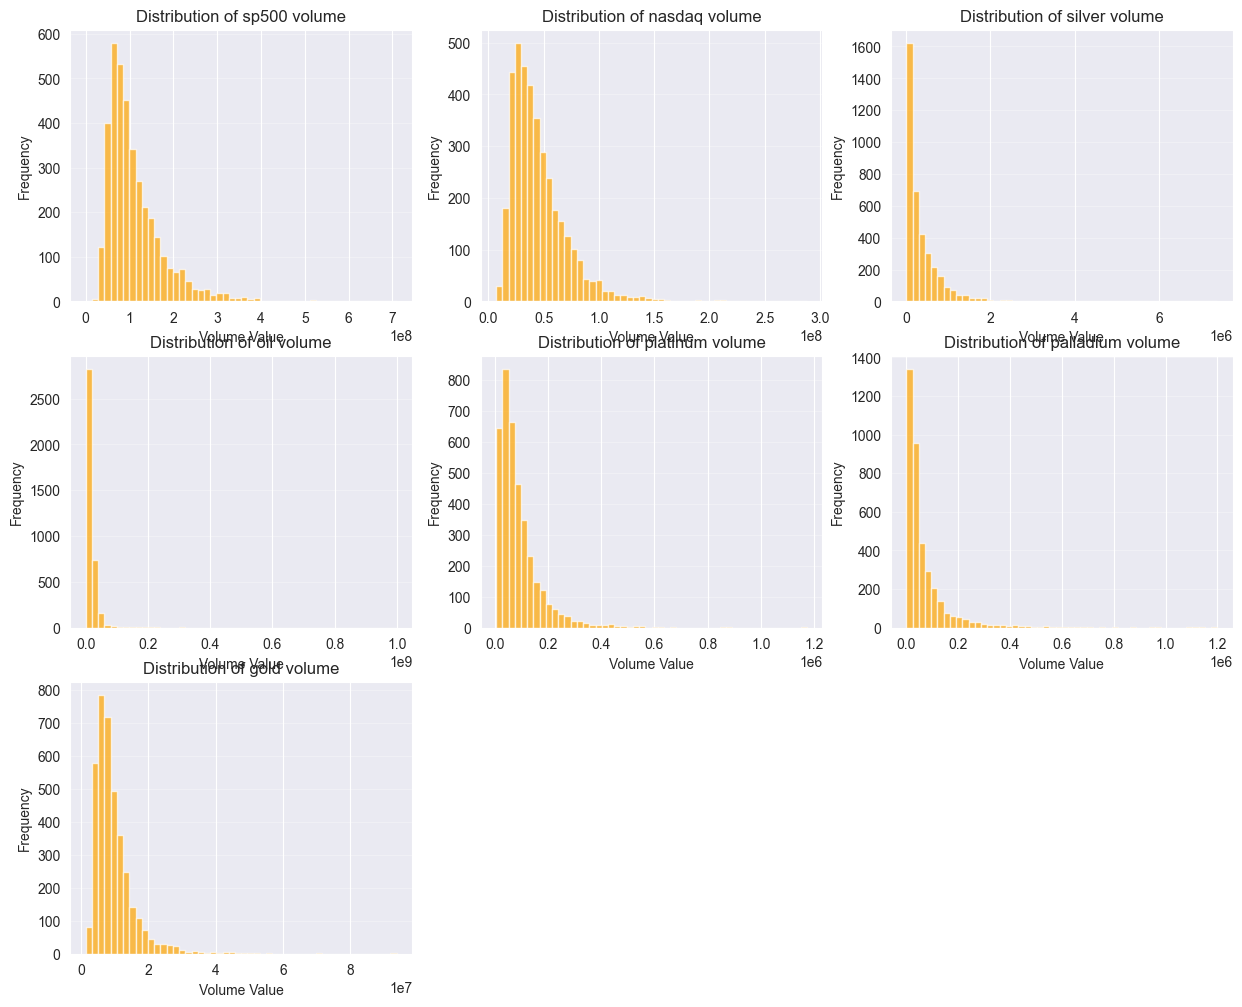

In [3]:
normalized_financial_regression['date'] = pd.to_datetime(normalized_financial_regression['date'])
normalized_financial_regression.set_index('date', inplace=True, drop=False)
#Set date as index
volume_cols = [col for col in normalized_financial_regression.columns if 'volume' in col.lower()]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(volume_cols):
    axes[i].hist(normalized_financial_regression[col].dropna(), bins=50, color='orange', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Volume Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', alpha=0.3)
fig.delaxes(axes[7])
fig.delaxes(axes[8])

#### Тут я віришив показати хістограмами об'єми, тобто, показавши яке середнє значення, бо якщо значення нижче за середнє, то настрій на ринку в'ялий, торгувати не варто, а якщо більше, це свідчить про нестабільність на ринку, що може бути гарною можливістю для торгів, але варто бути обережним через високу волатильність

<Figure size 640x480 with 0 Axes>

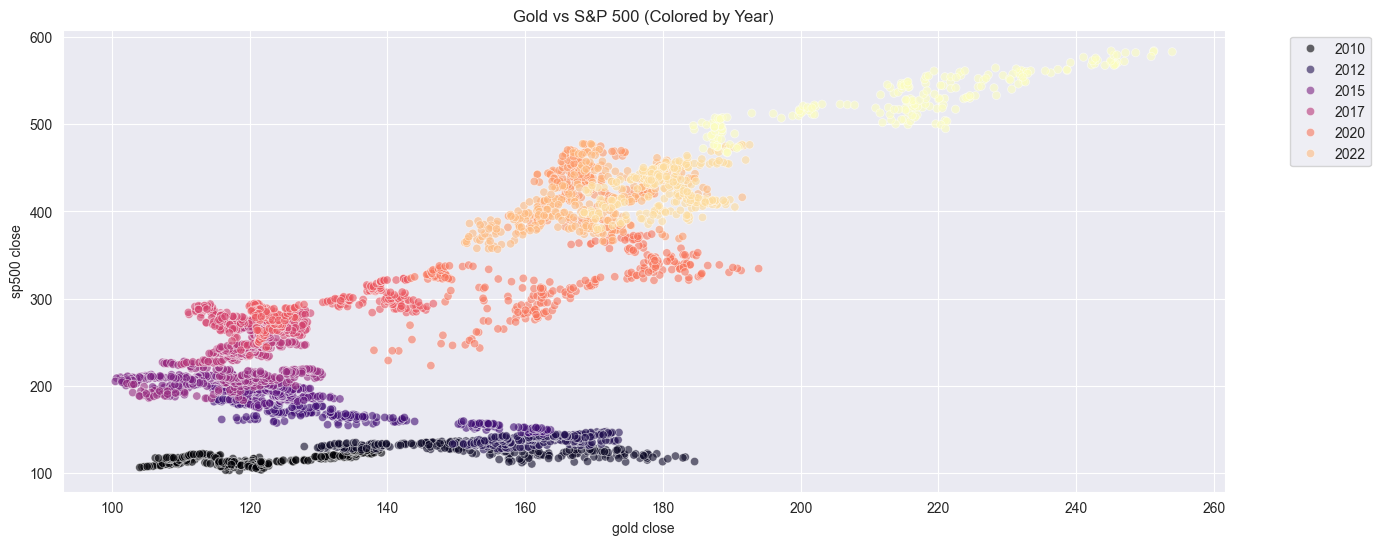

In [4]:
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))
sns.scatterplot(data=normalized_financial_regression,
                x='gold close',
                y='sp500 close',
                hue=normalized_financial_regression.index.year,
                palette='magma',
                alpha=0.6)
plt.title('Gold vs S&P 500 (Colored by Year)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### Тут можна побачити, що немає прям велких розбіжностей(жовті точки в своїй області, а білі - в своїй), видно, що найчастіше обидва активи ростуть

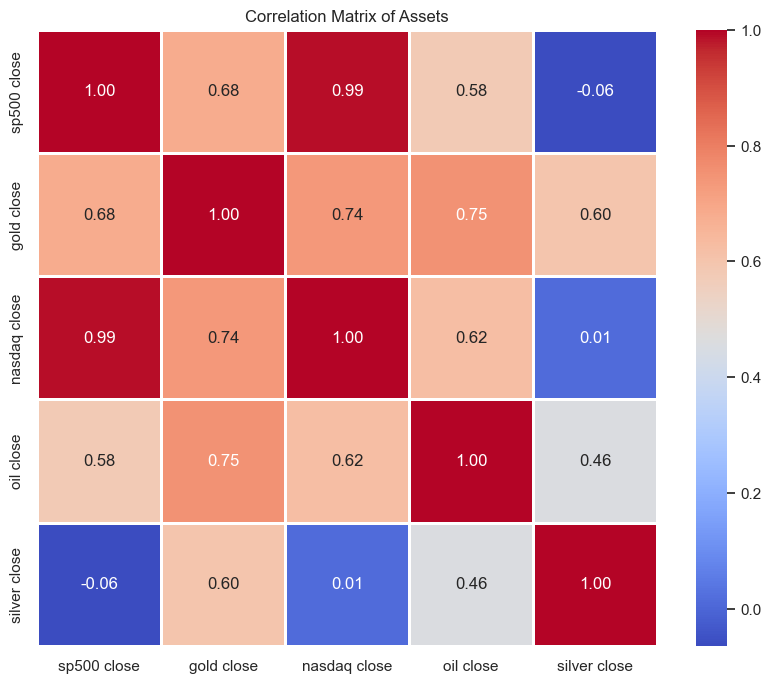

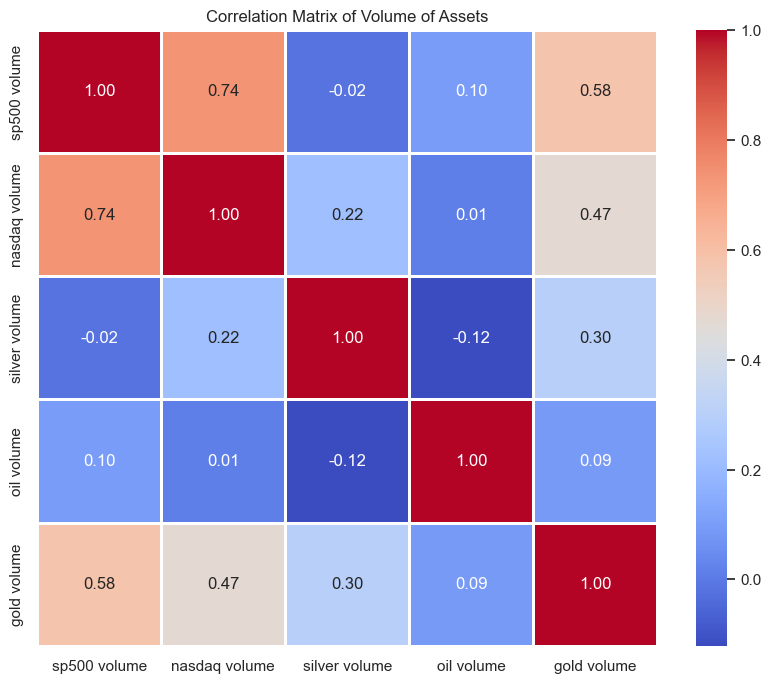

In [5]:
sns.set_theme(style="white", palette="viridis")

cols = ['sp500 close', 'gold close', 'nasdaq close', 'oil close', 'silver close']
df_corr = normalized_financial_regression[cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title('Correlation Matrix of Assets')
plt.show()

vol_cols = ['sp500 volume', 'nasdaq volume', 'silver volume', 'oil volume', 'gold volume']
df_corr = normalized_financial_regression[vol_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title('Correlation Matrix of Volume of Assets')
plt.show()

#### Seaborn в даному випадку є найкращим вибором, якщо ми хочемо побачити кореляцію між активами, а тема coolwarm наглядно показує, які активи корелюють краще за все, а які найменьше. На графіку ми бачимо, що найкращє корелюють Насдак і СНП, бо всі 100 активів Насдаку входять в корзину СНП, також непогано корелюють золото і нафта, бо ріст нафти розганає інфляцію і змушує інвесторів виходит в риск-оф активи. Також індекси і золото корелюють, бо коли ростуть індекси, це означає гарну ситуацію для економіки і інвестори беруть усе, що можна. На другому графіку можна побачити, що об'єми майже не корелюють, окрім індексів(між собою) і СНП та золота, що підтверджує гіпотезу про ріст індексів і золота в гарних для економіки умовах, такоє тут можна побачити навіть обратну кореліцію, це означає, що коли 1 актив росте, інший падає, як от наприклад срібло і нафта.

## Feature Engineering and Encoding

In [6]:
# Видалимо рідок індексів, бо він нам ніякої інформації не дає
normalized_financial_regression.reset_index(drop=True)
# Розділимо волатильність S&P 500 на "Low", "Medium", "High"
df_final = normalized_financial_regression.copy()
df_final["year"] = df_final["date"].dt.year
df_final["month"] = df_final["date"].dt.month
df_final["day"] = df_final["date"].dt.day
# 3. Encoding
# Label Encoding для порядкової категорії (Volatility: Low < Medium < High)
df_final['volatility_category'] = pd.qcut(df_final['sp500 high-low'], 3, labels=['Low', 'Medium', 'High'])
vol_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df_final['volatility_category'] = df_final['volatility_category'].map(vol_mapping)

# One-Hot Encoding для дня тижня (номінальна категорія, бо вівторок не більше понеділка)
# Створимо даммі змінні, щоб система розуміла сезонність
df_final = pd.get_dummies(df_final, columns=['month'], prefix='month')

# 4. Видалення непотрібних колонок
# Видаляємо date, бо усе корисне ми вже дістали
df_final.drop(columns=['date'], inplace=True)

print("After Feature Engineering")
print(df_final.head())
print(df_final.columns)
print(normalized_financial_regression.head(10))

After Feature Engineering
            sp500 open  sp500 high  sp500 low  sp500 close  sp500 volume  \
date                                                                       
2010-01-14      114.49      115.14     114.42       114.93   115646960.0   
2010-01-15      114.73      114.84     113.20       113.64   212252769.0   
2010-01-19      113.62      115.13     113.59       115.06   138671890.0   
2010-01-20      114.28      114.45     112.98       113.89   216330645.0   
2010-01-21      113.92      114.27     111.56       111.70   344747028.0   

            sp500 high-low  nasdaq open  nasdaq high  nasdaq low  \
date                                                               
2010-01-14            0.72        46.26       46.520       46.22   
2010-01-15            1.64        46.46       46.550       45.65   
2010-01-19            1.54        45.96       46.640       45.95   
2010-01-20            1.47        46.27       46.604       45.43   
2010-01-21            2.71       

## Final Data Preparation and Scaling

In [7]:
#Скейлимо нумеровані значення, а Null значення видаляємо, якщо вони і залишилися, то їх дуже мало(<2%)
features_to_scale = df_final.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
df_final[features_to_scale] = scaler.fit_transform(df_final[features_to_scale])
df_final.dropna(inplace=True)

# Переводимо усі булеві колонки в числові(0 або 1)
for col in df_final.select_dtypes(include=['bool']).columns:
    df_final[col] = df_final[col].astype(int)

# Якщо volatility_category ще не числова (а тип category), перетворюємо в int
if df_final['volatility_category'].dtype.name == 'category':
    df_final['volatility_category'] = df_final['volatility_category'].astype(int)

# Збереження файлу
df_final.to_csv("financial_data_final_ML.csv", index=False)
print("Final sanity check")
df_final.info()

print(f"\nTotal Missing values {df_final.isnull().sum().sum()}")

print(f" Non-numeric columns: {df_final.select_dtypes(exclude=[np.number]).columns.tolist()}")

df_final.to_csv("financial_data_final_ML.csv", index = False)
print("File successfully saved")

Final sanity check
<class 'pandas.DataFrame'>
DatetimeIndex: 3742 entries, 2010-04-01 to 2024-10-23
Data columns (total 61 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sp500 open           3742 non-null   float64
 1   sp500 high           3742 non-null   float64
 2   sp500 low            3742 non-null   float64
 3   sp500 close          3742 non-null   float64
 4   sp500 volume         3742 non-null   float64
 5   sp500 high-low       3742 non-null   float64
 6   nasdaq open          3742 non-null   float64
 7   nasdaq high          3742 non-null   float64
 8   nasdaq low           3742 non-null   float64
 9   nasdaq close         3742 non-null   float64
 10  nasdaq volume        3742 non-null   float64
 11  nasdaq high-low      3742 non-null   float64
 12  us_rates_%           3742 non-null   float64
 13  CPI                  3742 non-null   float64
 14  usd_chf              3742 non-null   float64
 15  eur_usd     

#### 0 в графі нульових значень і те, що немає не числових колонок, показує, що датасет достатьно підготовлений для машинного навчання